# Beyond BLAST: generalized window functions

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


Main.blast_tutorials

In [2]:
include("blast_code/src/new_funcs.jl")

compute_T̃_beyond (generic function with 1 method)

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Revise
using SpecialFunctions
using .Blast
using .blast_tutorials

In [4]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array of background redshifts
χ_b = npzread("blast_code/data/background/chi.npy") # array of background comoving distances 
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # an array of z(\chi)

In [5]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [6]:
#Interpolating the power spectrum
#Linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))

InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

In [7]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
counter = 1

for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end

ll_reshaped = zeros(dtype, length(ell), 5, 5)
counter = 1

for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end

gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1

for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [8]:
ℓ = Blast.ℓ
n_chi = 2 # number of comoving "bins"
x_min = 26 # minimum comoving distance
x_max = 7000 # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi) # array of comoving distances
R = chebpoints(n_chi, -1, 1) # array of ratios
R = reverse(R[R.>0])
nR = length(R) # number of ratios R
kmax = 200/13 # maximum wavenumber (small scales)
kmin = 2.5/x_max # minimum wavenumber (large scales)
n_cheb = 2 # number of Chebyshev nodes 
β = 2 # exponent depending on the probe
      # 0 for Galaxy - Shear, 
      # 2 for Galaxy - Galaxy, 
      # -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
# Define k' and k'' on Chebyshev grid
kp = kpp = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''
N = 2^(15)+1 # number of integration points

32769

In [11]:
# Refactored T̃ computation: single k-integral via (p,q) Chebyshev indices
# Output shape per ℓ: (n_chi, nR, n_cheb+1)  — no k'/k'' dimensions

computation_time = @elapsed begin
    T_LL = zeros(length(ℓ), n_chi, nR, n_cheb + 1)
    T_CL = zeros(length(ℓ), n_chi, nR, n_cheb + 1)
    T_CC = zeros(length(ℓ), n_chi, nR, n_cheb + 1)

    for i in eachindex(ℓ)
        T_LL[i,:,:,:], T_CL[i,:,:,:], T_CC[i,:,:,:] =
            compute_T̃(ℓ[i], χ, R, kmin, kmax;
                          n_cheb     = n_cheb,
                          N          = N,
                          power_spectrum = power_spectrum)
        println("step ", i, " completed")
    end
end

open(joinpath(output_dir, "parameters.txt"), "a") do f
    write(f, "\nComputation Time (v2):\n")
    write(f, "T̃ computation time: $(computation_time) s ($(computation_time/60) min)\n")
end
println("Computation took: $(computation_time) seconds")

LoadError: UndefVarError: `compute_T̃` not defined

In [ ]:
#Shapes are (length(ℓ), n_chi, nR, n_cheb+1)
print("Shape of the computed T̃_LL: ", size(T_LL), "\n")
print("Shape of the computed T̃_CL: ", size(T_CL), "\n")
print("Shape of the computed T̃_CC: ", size(T_CC), "\n")

Shape of the computed T̃_LL: (22, 98, 49, 120)
Shape of the computed T̃_CL: (22, 98, 49, 120)
Shape of the computed T̃_CC: (22, 98, 49, 120)


In [ ]:
cosmo = Blast.FlatΛCDM()
z_range = z_of_χ.(χ)
bgrid = Blast.CosmologicalGrid(z_range = z_range)
bg = Blast.BackgroundQuantities(Hz_array = zeros(length(z_range)), χz_array = Array(χ));

In [ ]:
cheb_coeff = zeros(n_chi, nR, n_cheb + 1)
vals = power_spectrum.(10 .^ k_cheb, χ[1], χ[1] * R[1])
plan = Blast.plan_fft(vals)

for i in 1:nR
    for j in 1:n_chi
        vals = power_spectrum.(10 .^ k_cheb, χ[j], χ[j] * R[i])
        cheb_coeff[j, i, :] = Blast.fast_chebcoefs(vals, plan)
    end
end
println("size of the chebyshev coefficients term")
println(size(cheb_coeff))
println("size of the computed T̃ term")
println(size(T_LL))

size of the chebyshev coefficients term
(98, 49, 120)
size of the computed T̃ term
(22, 98, 49, 120)


In [ ]:
# Continue as before with w_ell_tullio
w_LL = Blast.w_ell_tullio(cheb_coeff, T_LL)
w_CL = Blast.w_ell_tullio(cheb_coeff, T_CL)
w_CC = Blast.w_ell_tullio(cheb_coeff, T_CC);

In [ ]:
@benchmark Blast.w_ell_tullio(cheb_coeff, T_LL)

BenchmarkTools.Trial: 890 samples with 1 evaluation per sample.
 Range (min … max):  4.881 ms … 57.577 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     5.176 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   5.604 ms ±  2.514 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

   ▅█▇▆▄▃▁▁     ▁                                             
  ▇██████████▄█▇█▇▇▇██▇▇▇█▆▅▆▆▄▅▄▅▅▄▅▅▁▄▁▄▄▅▁▁▄▄▁▁▁▄▁▁▁▁▄▁▄▅ █
  4.88 ms      Histogram: log(frequency) by time     9.62 ms <

 Memory estimate: 825.44 KiB, allocs estimate: 2.

Saved: run_20260518_103356/plots/wLL_ell2.png


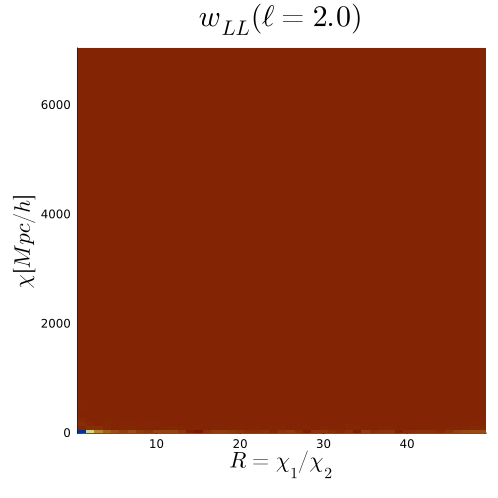

In [ ]:
p1 = heatmap(1:nR, χ, w_LL[1,:,:]./maximum(w_LL[1,:,:]), size = (500,500), title=L"w_{LL}(ℓ=2.0)", 
    c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p1, "wLL_ell2")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing,axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

Saved: run_20260518_103356/plots/wLL_ell211.png


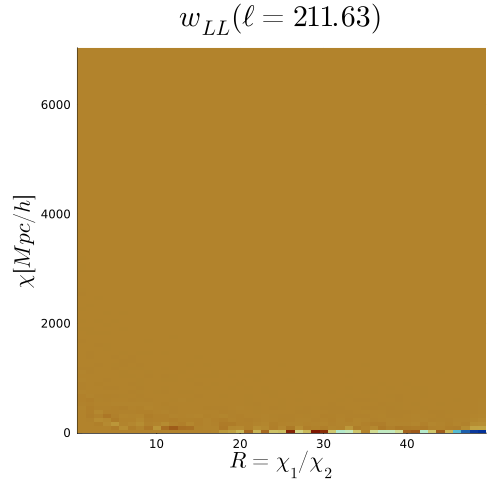

In [ ]:
p2 = heatmap(1:nR, χ, w_LL[22,:,:]./maximum(w_LL[22,:,:]), size = (500,500), title=L"w_{LL}(ℓ=211.63)",
    legend = :none, c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]",
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)
save_plot(p2, "wLL_ell211")

# plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(11, 7300, text(L"R=0.5",14), :black)

# plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
# annotate!(23, 7300, text(L"R=0.8",14), :black)

# plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5",axis=([], false), size = (500,500)) 
# annotate!(34, 7400, text(L"R=0.9",14), :black)

In [ ]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")

Dict{String, Array{Float64}} with 4 entries:
  "dNdz_cl" => [9.51877e-8 1.11093e-13 … 5.97529e-61 6.25179e-67; 1.246e-7 1.56…
  "z_sh"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…
  "dNdz_sh" => [0.106801 1.52148e-9 … 6.04656e-24 7.57113e-34; 0.111443 1.76706…
  "z_cl"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…

In [ ]:
GalKernels = Blast.GalaxyKernel(10, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_cl"]',  n5k_bins["z_cl"], GalKernels, bgrid, bg, cosmo)

In [ ]:
ShearKernels = Blast.ShearKernel(4, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_sh"]', n5k_bins["z_sh"], ShearKernels, bgrid, bg, cosmo)

In [ ]:
#Loading the N5K pre-computed kernel to check that they match!
W = npzread("blast_code/data/kernels_fullwidth.npz")

Dict{String, Array{Float64}} with 6 entries:
  "chi_cl"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_sh" => [6.04145e-7 7.78856e-7 … 0.0 0.0; 6.14932e-7 7.9704e-7 … 0.0 …
  "z_sh"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…
  "chi_sh"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_cl" => [0.0 1.02182e-10 … 0.0 0.0; 0.0 9.54391e-17 … 0.0 0.0; … ; 0.…
  "z_cl"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…

Saved: run_20260518_103356/plots/clustering_kernels.png


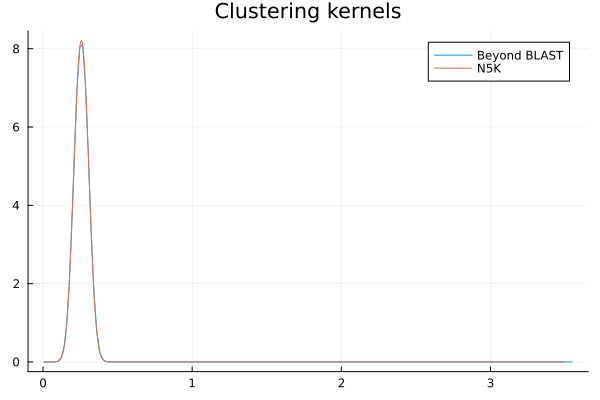

In [ ]:
i_bin = 1

interp = DataInterpolations.AkimaInterpolation( W["kernels_cl"][i_bin,:], W["z_cl"], extrapolation = ExtrapolationType.Linear)
intn, _ = quadgk(x -> interp.(x), 0., 3.5)

interp = DataInterpolations.AkimaInterpolation( GalKernels.Kernel[i_bin,:], bgrid.z_range, extrapolation = ExtrapolationType.Linear)
intb, _ = quadgk(x -> interp.(x), 0., 3.5)

p3 = plot(bgrid.z_range, GalKernels.Kernel[i_bin,:]/intb, label="Beyond BLAST", title = "Clustering kernels")
plot!(p3, W["z_cl"], W["kernels_cl"][i_bin,:]/intn, label="N5K")
save_plot(p3, "clustering_kernels")

Saved: run_20260518_103356/plots/shear_kernels.png


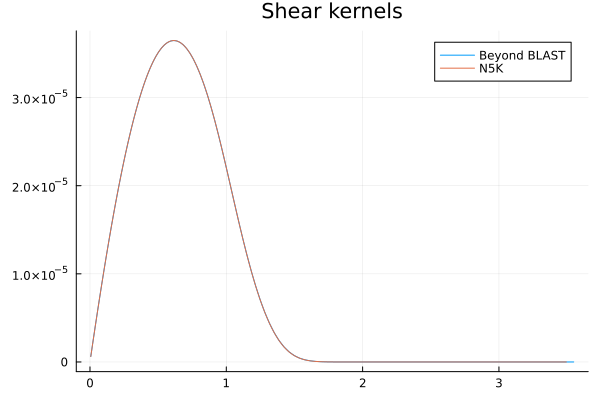

In [ ]:
bin = 4

p4 = plot(bgrid.z_range, ShearKernels.Kernel[bin,:], label="Beyond BLAST", title = "Shear kernels")
plot!(p4, W["z_sh"], W["kernels_sh"][bin,:], label="N5K")
save_plot(p4, "shear_kernels")

In [ ]:
K_CC, K_CL, K_LL = blast_tutorials.compute_kernels(W, χ, R)
w_χ = Blast.simpson_weight_array(n_chi)
w_R = Blast.get_clencurt_weights_R_integration(2*nR+1)
pref_CC = Blast.get_ell_prefactor(GalKernels, GalKernels, ℓ)
pref_CL = Blast.get_ell_prefactor(ShearKernels, GalKernels, ℓ)
pref_LL = Blast.get_ell_prefactor(ShearKernels, ShearKernels, ℓ);

In [ ]:
clustering_Cℓ = Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)
shear_Cℓ = Blast.compute_Cℓ(w_LL, K_LL, bg, w_χ, w_R, pref_LL)
cross_Cℓ = Blast.compute_Cℓ(w_CL, K_CL, bg, w_χ, w_R, pref_CL);

In [ ]:
#dtype = Float64
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))
Cℓ_CL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_linear_full.npy"))
Cℓ_LL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_linear_full.npy"))
Cℓ_CC_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_nl_full.npy"))
Cℓ_CL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_nl_full.npy"))
Cℓ_LL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_nl_full.npy"));

In [ ]:
final_clustering_Cℓ = clustering_Cℓ + Cℓ_CC_limb_nl - Cℓ_CC_limb
final_cross_Cℓ = cross_Cℓ + Cℓ_CL_limb_nl - Cℓ_CL_limb
final_shear_Cℓ = shear_Cℓ + Cℓ_LL_limb_nl - Cℓ_LL_limb;

In [ ]:
# Load extended Limber for ℓ>200, but with different variable names
Cℓ_CC_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber+200_full.npy"))
Cℓ_CL_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber+200_full.npy"))
Cℓ_LL_limb_ext = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber+200_full.npy"))

# Concatenate with your computed results (keep originals for correction)
total_Cℓ_CC = cat(final_clustering_Cℓ, Cℓ_CC_limb_ext, dims=1)
total_Cℓ_CL = cat(final_cross_Cℓ, Cℓ_CL_limb_ext, dims=1)
total_Cℓ_LL = cat(final_shear_Cℓ, Cℓ_LL_limb_ext, dims=1);

In [ ]:
# Interpolating to go on the same n5k grid
elle = dtype.(reverse(chebpoints(100, 2, 2000)))
ℓ_min = 2
ℓ_max = 2000

interp_Cℓ_CC = zeros(dtype, length(ell), 10, 10)  # ← ell → elle
interp_Cℓ_CL = zeros(dtype, length(ell), 10, 5)
interp_Cℓ_LL = zeros(dtype, length(ell), 5, 5)

for i in 1:10
    for j in i:10
        interpol = chebinterp(reverse(total_Cℓ_CC[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CC[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_CC[:,j,i] = interp_Cℓ_CC[:,i,j]
    end
end

for i in 1:10
    for j in 1:5
        interpol = chebinterp(reverse(total_Cℓ_CL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
    end
end

for i in 1:5
    for j in i:5
        interpol = chebinterp(reverse(total_Cℓ_LL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_LL[:,i,j] = interpol.(ell) ./ (ell.*ell)  # ← ell → elle
        interp_Cℓ_LL[:,j,i] = interp_Cℓ_LL[:,i,j]
    end
end

Saved: run_20260518_103356/plots/Cℓ_gg_linear_scale.png


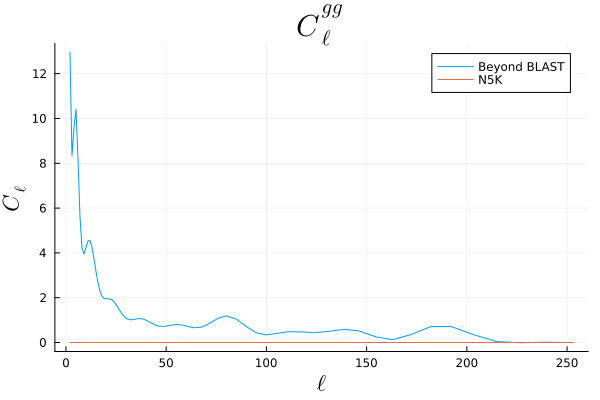

In [ ]:
i = 10
j = 10
nl = 65 #set this to 103 to see up to ℓ=2000.
p5 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j], label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(p5, ell[1:nl], gg_reshaped[1:nl,i,j], label = "N5K")
save_plot(p5, "Cℓ_gg_linear_scale")

Saved: run_20260518_103356/plots/Cℓ_gg_ell_scaling.png


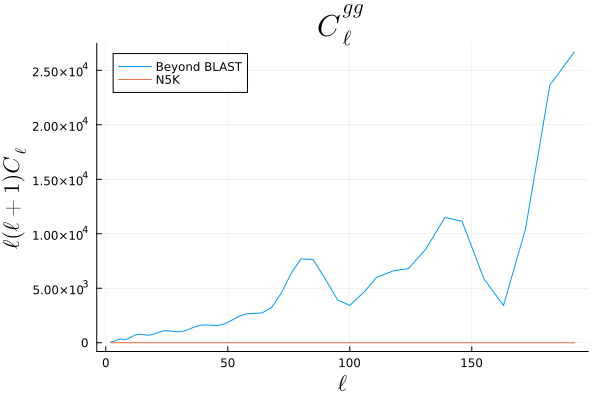

In [ ]:
i = 10
j = 10
nl = 60 #set this to 103 to see up to ℓ=2000.
p6 = plot(ell[1:nl], interp_Cℓ_CC[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="Beyond BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(p6, ell[1:nl], gg_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p6, "Cℓ_gg_ell_scaling")

Saved: run_20260518_103356/plots/Cℓ_gs_linear_scale.png


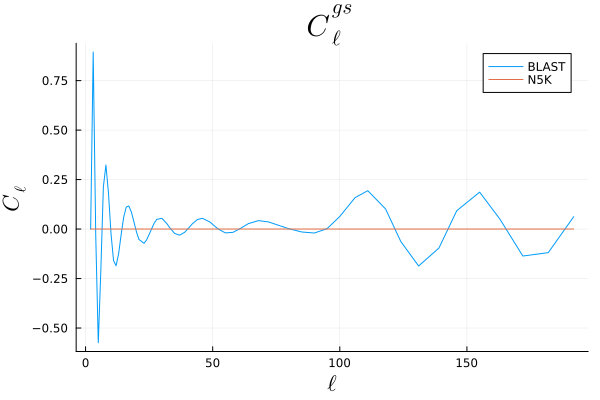

In [ ]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p7 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j], label = "N5K")
save_plot(p7, "Cℓ_gs_linear_scale")

Saved: run_20260518_103356/plots/Cℓ_gs_ell_scaling.png


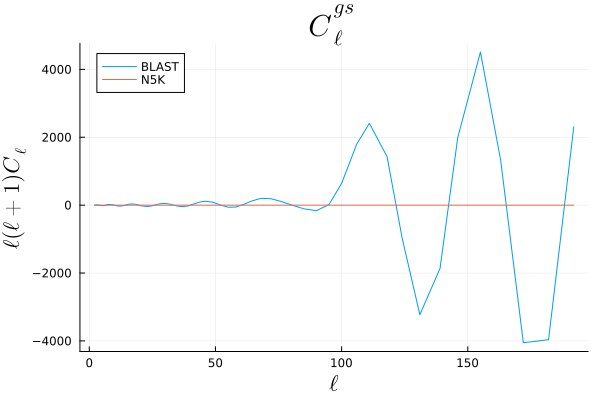

In [ ]:
i = 1
j = 2
nl = 60 #set this to 103 to see up to ℓ=2000.
p8 = plot(ell[1:nl], interp_Cℓ_CL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{gs}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gl_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_gs_ell_scaling")

Saved: run_20260518_103356/plots/Cℓ_ss_linear_scale.png


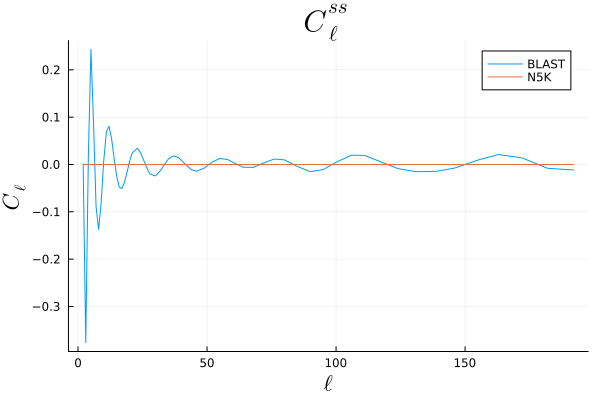

In [ ]:
i = 3
j = 3
nl = 60 #set this to 103 to see up to ℓ=2000.
p9 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j], label="BLAST", title = L"$C_\ell^{ss}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j], label = "N5K")
save_plot(p9, "Cℓ_ss_linear_scale")

Saved: run_20260518_103356/plots/Cℓ_ss_ell_scaling.png


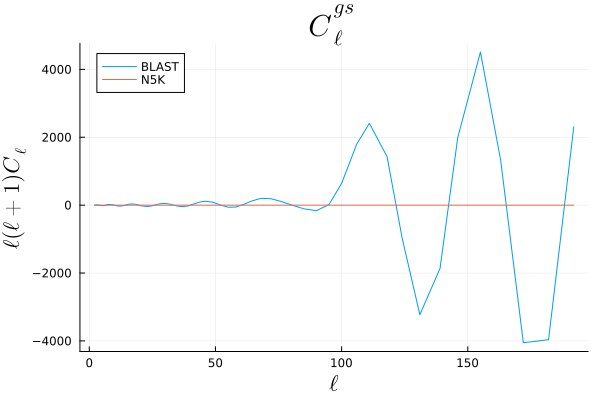

In [ ]:
i = 3
j = 3
nl = 103 #set this to 103 to see up to ℓ=2000.
p10 = plot(ell[1:nl], interp_Cℓ_LL[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label="BLAST", title = L"$C_\ell^{aa}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], ll_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")
save_plot(p8, "Cℓ_ss_ell_scaling")

In [ ]:
using NPZ

# After all computations, save everything
npzwrite(joinpath(output_dir, "results.npz"), Dict(
    "T_LL" => T_LL,
    "T_CL" => T_CL,
    "T_CC" => T_CC,
    "w_LL" => w_LL,
    "w_CL" => w_CL,
    "w_CC" => w_CC,
    "clustering_Cℓ" => clustering_Cℓ,
    "shear_Cℓ" => shear_Cℓ,
    "cross_Cℓ" => cross_Cℓ,
    "k" => k,
    "z" => z,
    "Pklin" => Pklin,
    "Pknonlin" => Pknonlin
))